In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', 100)

In [4]:
app_train = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')
bureau_balance = pd.read_csv('bureau_balance.csv')
previous_app = pd.read_csv('previous_application.csv')
pos_cash = pd.read_csv('POS_CASH_balance.csv')
credit_card = pd.read_csv('credit_card_balance.csv')
installments = pd.read_csv('installments_payments.csv')

print("app_train:", app_train.shape)
print("bureau:", bureau.shape)
print("bureau_balance:", bureau_balance.shape)
print("previous_app:", previous_app.shape)
print("pos_cash:", pos_cash.shape)
print("credit_card:", credit_card.shape)
print("installments:", installments.shape)

app_train: (307511, 122)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
previous_app: (1670214, 37)
pos_cash: (10001358, 8)
credit_card: (3840312, 23)
installments: (13605401, 8)


In [5]:
# Check target distribution
print("Target distribution:")
print(app_train['TARGET'].value_counts())
print()
print(app_train['TARGET'].value_counts(normalize=True).round(3) * 100)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.9
1     8.1
Name: proportion, dtype: float64


In [6]:
# Basic overview of main file
print("Shape:", app_train.shape)
print()
print("First look at data:")
app_train.head()

Shape: (307511, 122)

First look at data:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

In [7]:
# Missing value analysis
missing = app_train.isnull().sum()
missing_percent = (missing / len(app_train)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)
print(f"Columns with missing values: {len(missing_df)} out of {app_train.shape[1]}")
print()
print(missing_df.head(20))

Columns with missing values: 67 out of 122

                          Missing Values  Percentage
COMMONAREA_MEDI                   214865   69.872297
COMMONAREA_MODE                   214865   69.872297
COMMONAREA_AVG                    214865   69.872297
NONLIVINGAPARTMENTS_MODE          213514   69.432963
NONLIVINGAPARTMENTS_MEDI          213514   69.432963
NONLIVINGAPARTMENTS_AVG           213514   69.432963
FONDKAPREMONT_MODE                210295   68.386172
LIVINGAPARTMENTS_AVG              210199   68.354953
LIVINGAPARTMENTS_MEDI             210199   68.354953
LIVINGAPARTMENTS_MODE             210199   68.354953
FLOORSMIN_MEDI                    208642   67.848630
FLOORSMIN_MODE                    208642   67.848630
FLOORSMIN_AVG                     208642   67.848630
YEARS_BUILD_MODE                  204488   66.497784
YEARS_BUILD_MEDI                  204488   66.497784
YEARS_BUILD_AVG                   204488   66.497784
OWN_CAR_AGE                       202929   65.990810
LA

In [8]:
print("Data types:")
print(app_train.dtypes.value_counts())
print()
print("Numerical columns:", app_train.select_dtypes(include=np.number).shape[1])
print("Categorical columns:", app_train.select_dtypes(include='object').shape[1])

Data types:
float64    65
int64      41
object     16
Name: count, dtype: int64

Numerical columns: 106
Categorical columns: 16


In [9]:
cat_cols = app_train.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {app_train[col].nunique()} unique values → {app_train[col].unique()[:5]}")

NAME_CONTRACT_TYPE: 2 unique values → ['Cash loans' 'Revolving loans']
CODE_GENDER: 3 unique values → ['M' 'F' 'XNA']
FLAG_OWN_CAR: 2 unique values → ['N' 'Y']
FLAG_OWN_REALTY: 2 unique values → ['Y' 'N']
NAME_TYPE_SUITE: 7 unique values → ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A']
NAME_INCOME_TYPE: 8 unique values → ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed']
NAME_EDUCATION_TYPE: 5 unique values → ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
NAME_FAMILY_STATUS: 6 unique values → ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated']
NAME_HOUSING_TYPE: 6 unique values → ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment']
OCCUPATION_TYPE: 18 unique values → ['Laborers' 'Core staff' 'Accountants' 'Managers' nan]
WEEKDAY_APPR_PROCESS_START: 7 unique values → ['WEDNESDAY' 'MONDAY' 'THURSDAY' 'SUNDAY' 'SATURDAY

In [10]:
print("Data types:")
print(app_train.dtypes.value_counts())
print()
print("Numerical columns:", app_train.select_dtypes(include=np.number).shape[1])
print("Categorical columns:", app_train.select_dtypes(include='object').shape[1])

Data types:
float64    65
int64      41
object     16
Name: count, dtype: int64

Numerical columns: 106
Categorical columns: 16


In [11]:
cat_cols = app_train.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {app_train[col].nunique()} unique values → {app_train[col].unique()[:5]}")

NAME_CONTRACT_TYPE: 2 unique values → ['Cash loans' 'Revolving loans']
CODE_GENDER: 3 unique values → ['M' 'F' 'XNA']
FLAG_OWN_CAR: 2 unique values → ['N' 'Y']
FLAG_OWN_REALTY: 2 unique values → ['Y' 'N']
NAME_TYPE_SUITE: 7 unique values → ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A']
NAME_INCOME_TYPE: 8 unique values → ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed']
NAME_EDUCATION_TYPE: 5 unique values → ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
NAME_FAMILY_STATUS: 6 unique values → ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated']
NAME_HOUSING_TYPE: 6 unique values → ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment']
OCCUPATION_TYPE: 18 unique values → ['Laborers' 'Core staff' 'Accountants' 'Managers' nan]
WEEKDAY_APPR_PROCESS_START: 7 unique values → ['WEDNESDAY' 'MONDAY' 'THURSDAY' 'SUNDAY' 'SATURDAY

In [12]:
# Step 1: Aggregate bureau.csv
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    total_loans = ('SK_ID_BUREAU', 'count'),
    active_loans = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    closed_loans = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    avg_credit_amount = ('AMT_CREDIT_SUM', 'mean'),
    total_credit_amount = ('AMT_CREDIT_SUM', 'sum'),
    avg_credit_overdue = ('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    avg_days_credit = ('DAYS_CREDIT', 'mean')
).reset_index()

print("Bureau aggregated shape:", bureau_agg.shape)
bureau_agg.head()

Bureau aggregated shape: (305811, 8)


,SK_ID_CURR,total_loans,active_loans,closed_loans,avg_credit_amount,total_credit_amount,avg_credit_overdue,avg_days_credit
0,100001,7,3,4,207623.571429,1453365.000,0.0,-735.000000
1,100002,8,2,6,108131.945625,865055.565,0.0,-874.000000
2,100003,4,1,3,254350.125000,1017400.500,0.0,-1400.750000
3,100004,2,0,2,94518.900000,189037.800,0.0,-867.000000
4,100005,3,2,1,219042.000000,657126.000,0.0,-190.666667


In [13]:
# Step 1: Aggregate bureau_balance to one row per bureau loan
bureau_bal_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
    total_months = ('MONTHS_BALANCE', 'count'),
    dpd_count = ('STATUS', lambda x: (x.isin(['1','2','3','4','5'])).sum()),
    paid_on_time = ('STATUS', lambda x: (x == '0').sum())
).reset_index()

# Step 2: Merge with bureau to get SK_ID_CURR, then aggregate again
bureau_bal_agg = bureau_bal_agg.merge(
    bureau[['SK_ID_BUREAU', 'SK_ID_CURR']], 
    on='SK_ID_BUREAU', 
    how='left'
)

bureau_bal_agg = bureau_bal_agg.groupby('SK_ID_CURR').agg(
    avg_months_on_books = ('total_months', 'mean'),
    total_dpd_count = ('dpd_count', 'sum'),
    total_paid_on_time = ('paid_on_time', 'sum')
).reset_index()

print("Bureau balance aggregated shape:", bureau_bal_agg.shape)
bureau_bal_agg.head()

Bureau balance aggregated shape: (134542, 4)


,SK_ID_CURR,avg_months_on_books,total_dpd_count,total_paid_on_time
0,100001.0,24.571429,1,31
1,100002.0,13.750000,27,45
2,100005.0,7.000000,0,14
3,100010.0,36.000000,0,20
4,100013.0,57.500000,7,79


In [14]:
# Previous application aggregation
prev_app_agg = previous_app.groupby('SK_ID_CURR').agg(
    total_prev_applications = ('SK_ID_PREV', 'count'),
    approved_count = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    refused_count = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    avg_prev_credit = ('AMT_CREDIT', 'mean'),
    avg_prev_annuity = ('AMT_ANNUITY', 'mean')
).reset_index()

print("Previous app aggregated shape:", prev_app_agg.shape)

Previous app aggregated shape: (338857, 6)


In [15]:
# POS CASH aggregation
pos_cash_agg = pos_cash.groupby('SK_ID_CURR').agg(
    avg_pos_months = ('MONTHS_BALANCE', 'count'),
    avg_dpd_pos = ('SK_DPD', 'mean'),
    max_dpd_pos = ('SK_DPD', 'max')
).reset_index()

print("POS Cash aggregated shape:", pos_cash_agg.shape)

POS Cash aggregated shape: (337252, 4)


In [16]:
# Installments aggregation
install_agg = installments.groupby('SK_ID_CURR').agg(
    total_installments = ('NUM_INSTALMENT_NUMBER', 'count'),
    avg_payment_diff = ('AMT_INSTALMENT', 'mean'),
    avg_days_late = ('DAYS_ENTRY_PAYMENT', 'mean')
).reset_index()

print("Installments aggregated shape:", install_agg.shape)

Installments aggregated shape: (339587, 4)


In [17]:
# Credit card aggregation
credit_agg = credit_card.groupby('SK_ID_CURR').agg(
    avg_credit_limit = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    avg_balance = ('AMT_BALANCE', 'mean'),
    avg_drawings = ('AMT_DRAWINGS_CURRENT', 'mean'),
    avg_dpd_credit = ('SK_DPD', 'mean')
).reset_index()

print("Credit card aggregated shape:", credit_agg.shape)

Credit card aggregated shape: (103558, 5)


In [18]:
# Merge everything into app_train
df = app_train.copy()

df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(bureau_bal_agg, on='SK_ID_CURR', how='left')
df = df.merge(prev_app_agg, on='SK_ID_CURR', how='left')
df = df.merge(pos_cash_agg, on='SK_ID_CURR', how='left')
df = df.merge(install_agg, on='SK_ID_CURR', how='left')
df = df.merge(credit_agg, on='SK_ID_CURR', how='left')

print("Final master dataframe shape:", df.shape)

Final master dataframe shape: (307511, 147)


In [20]:
df.to_csv('master_df.csv', index=False)
print("Master dataframe saved!")

Master dataframe saved!


In [22]:
# Load master dataframe
df = pd.read_csv('master_df.csv')

# Drop columns with more than 50% missing values
threshold = 50
missing_percent = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()

print(f"Columns to drop (>50% missing): {len(cols_to_drop)}")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nShape after dropping: {df.shape}")

Columns to drop (>50% missing): 48
['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'avg_months_on_books', 'total_dpd_count', 'total_paid_on_time', 'avg_credit_limit', 'avg_balance', 'avg_drawings', 'avg_dpd_credit']

Shape after dropp

In [23]:
# Fix XNA in CODE_GENDER
df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', df['CODE_GENDER'].mode()[0])

# Fix XNA in ORGANIZATION_TYPE
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA', df['ORGANIZATION_TYPE'].mode()[0])

print("Unique values in CODE_GENDER:", df['CODE_GENDER'].unique())
print("XNA remaining:", (df['CODE_GENDER'] == 'XNA').sum())

Unique values in CODE_GENDER: ['M' 'F']
XNA remaining: 0


In [24]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Fill numerical missing values with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify no missing values remain
print("Total missing values remaining:", df.isnull().sum().sum())
print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Total missing values remaining: 0
Numerical columns: 86
Categorical columns: 13


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
print("Any object columns remaining:", df.select_dtypes(include='object').shape[1])
df.shape

Encoding done!
Any object columns remaining: 0


(307511, 99)

In [26]:
df.to_csv('cleaned_df.csv', index=False)
print("Cleaned dataframe saved!")

Cleaned dataframe saved!


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

df = pd.read_csv('cleaned_df.csv')

# Separate features and target
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

ModuleNotFoundError: No module named 'xgboost'

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'imbalanced-learn'])

CompletedProcess(args=['pip', 'install', 'xgboost', 'imbalanced-learn'], returncode=0)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

df = pd.read_csv('cleaned_df.csv')

# Separate features and target
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (307511, 97)
Target shape: (307511,)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [9]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nBefore SMOTE:")
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Train size: (246008, 97)
Test size: (61503, 97)

Before SMOTE:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE:
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [10]:
# Model 1 - Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Evaluate
lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results:")
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Training Logistic Regression...

Logistic Regression Results:
ROC-AUC Score: 0.6235

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.63      0.75     56538
           1       0.12      0.55      0.19      4965

    accuracy                           0.62     61503
   macro avg       0.53      0.59      0.47     61503
weighted avg       0.87      0.62      0.71     61503



In [11]:
# Model 2 - Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

# Evaluate
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results:")
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Training Random Forest...

Random Forest Results:
ROC-AUC Score: 0.6964

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.26      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.59      0.51      0.50     61503
weighted avg       0.87      0.92      0.88     61503



In [12]:
# Model 3 - XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train_sm, y_train_sm)

# Evaluate
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print("\nXGBoost Results:")
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))

Training XGBoost...

XGBoost Results:
ROC-AUC Score: 0.7198

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.33      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.63      0.51      0.50     61503
weighted avg       0.87      0.92      0.88     61503



In [13]:
# Adjust threshold for XGBoost
threshold = 0.3
xgb_preds_adjusted = (xgb_probs >= threshold).astype(int)

print(f"XGBoost Results with threshold={threshold}:")
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds_adjusted))

XGBoost Results with threshold=0.3:
ROC-AUC Score: 0.7198

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     56538
           1       0.25      0.19      0.22      4965

    accuracy                           0.89     61503
   macro avg       0.59      0.57      0.58     61503
weighted avg       0.88      0.89      0.88     61503



MODEL COMPARISON REPORT
Logistic Regression  ROC-AUC: 0.6235
Random Forest        ROC-AUC: 0.6964
XGBoost              ROC-AUC: 0.7198
Best Model: XGBoost with threshold=0.3


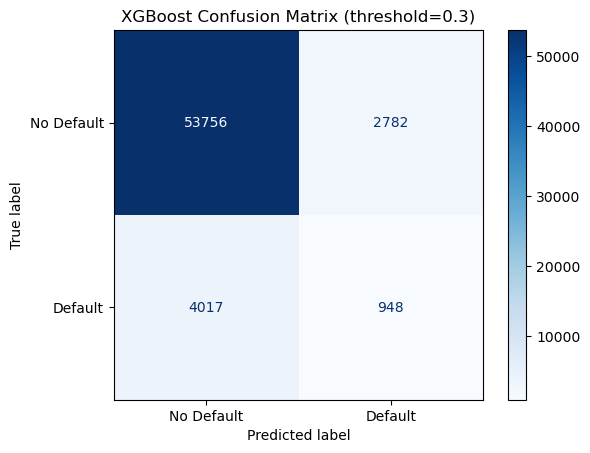

In [14]:
# Model Comparison Summary
print("=" * 50)
print("MODEL COMPARISON REPORT")
print("=" * 50)
print(f"Logistic Regression  ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"Random Forest        ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(f"XGBoost              ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")
print("=" * 50)
print("Best Model: XGBoost with threshold=0.3")

# Confusion Matrix for best model
cm = confusion_matrix(y_test, xgb_preds_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix (threshold=0.3)')
plt.show()

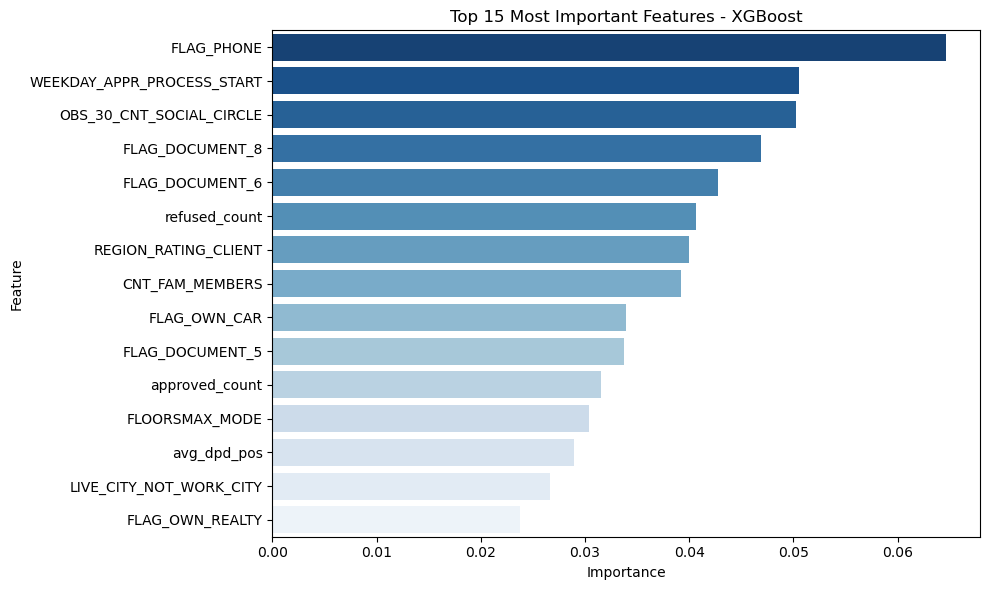

                       Feature  Importance
23                  FLAG_PHONE    0.064665
29  WEEKDAY_APPR_PROCESS_START    0.050509
48    OBS_30_CNT_SOCIAL_CIRCLE    0.050271
59             FLAG_DOCUMENT_8    0.046852
57             FLAG_DOCUMENT_6    0.042764
88               refused_count    0.040673
27        REGION_RATING_CLIENT    0.039977
26             CNT_FAM_MEMBERS    0.039217
2                 FLAG_OWN_CAR    0.033934
56             FLAG_DOCUMENT_5    0.033739
87              approved_count    0.031547
43              FLOORSMAX_MODE    0.030385
92                 avg_dpd_pos    0.028974
36     LIVE_CITY_NOT_WORK_CITY    0.026615
3              FLAG_OWN_REALTY    0.023797


In [15]:
# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='Blues_r')
plt.title('Top 15 Most Important Features - XGBoost')
plt.tight_layout()
plt.show()

print(feat_imp)

In [16]:
print("=" * 60)
print("PHASE 5 - BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
CONTEXT:
XGBoost model with ROC-AUC of 0.7198 and decision threshold 
of 0.3 is recommended for production deployment.

BUSINESS RECOMMENDATIONS:
================================================

1. PHONE VERIFICATION IS CRITICAL
   FLAG_PHONE is the #1 default predictor. The bank should 
   make phone number mandatory during application. Applicants 
   without verified phone numbers should be flagged for 
   additional scrutiny before loan approval.

2. SOCIAL CIRCLE RISK ASSESSMENT
   OBS_30_CNT_SOCIAL_CIRCLE is a top predictor. The bank 
   should consider the applicant's social environment as part 
   of risk assessment. Applicants from high-risk social 
   circles should be offered smaller loan amounts initially.

3. DOCUMENT SUBMISSION POLICY
   FLAG_DOCUMENT_6 and FLAG_DOCUMENT_8 are strong predictors.
   The bank should enforce strict document submission policies.
   Incomplete documentation should automatically trigger 
   additional verification steps.

4. PREVIOUS REFUSAL HISTORY
   refused_count from previous applications is a strong 
   signal. Applicants refused 3 or more times previously 
   should be considered high risk and offered loans only 
   with collateral or a guarantor.

5. USE 0.3 THRESHOLD IN PRODUCTION
   The default 0.5 threshold catches only 2% of defaulters.
   Using 0.3 threshold catches 19% of defaulters — nearly 
   10x improvement. This directly reduces financial losses 
   for the bank.

EXPECTED BUSINESS IMPACT:
================================================
- Catching 948 defaulters out of 4,965 in test set
- At average loan amount, this prevents significant 
  financial losses per prediction cycle
- Model should be retrained every 6 months as economic 
  conditions change
""")

PHASE 5 - BUSINESS RECOMMENDATIONS

CONTEXT:
XGBoost model with ROC-AUC of 0.7198 and decision threshold 
of 0.3 is recommended for production deployment.

BUSINESS RECOMMENDATIONS:

1. PHONE VERIFICATION IS CRITICAL
   FLAG_PHONE is the #1 default predictor. The bank should 
   make phone number mandatory during application. Applicants 
   without verified phone numbers should be flagged for 
   additional scrutiny before loan approval.

2. SOCIAL CIRCLE RISK ASSESSMENT
   OBS_30_CNT_SOCIAL_CIRCLE is a top predictor. The bank 
   should consider the applicant's social environment as part 
   of risk assessment. Applicants from high-risk social 
   circles should be offered smaller loan amounts initially.

3. DOCUMENT SUBMISSION POLICY
   FLAG_DOCUMENT_6 and FLAG_DOCUMENT_8 are strong predictors.
   The bank should enforce strict document submission policies.
   Incomplete documentation should automatically trigger 
   additional verification steps.

4. PREVIOUS REFUSAL HISTORY
   refu

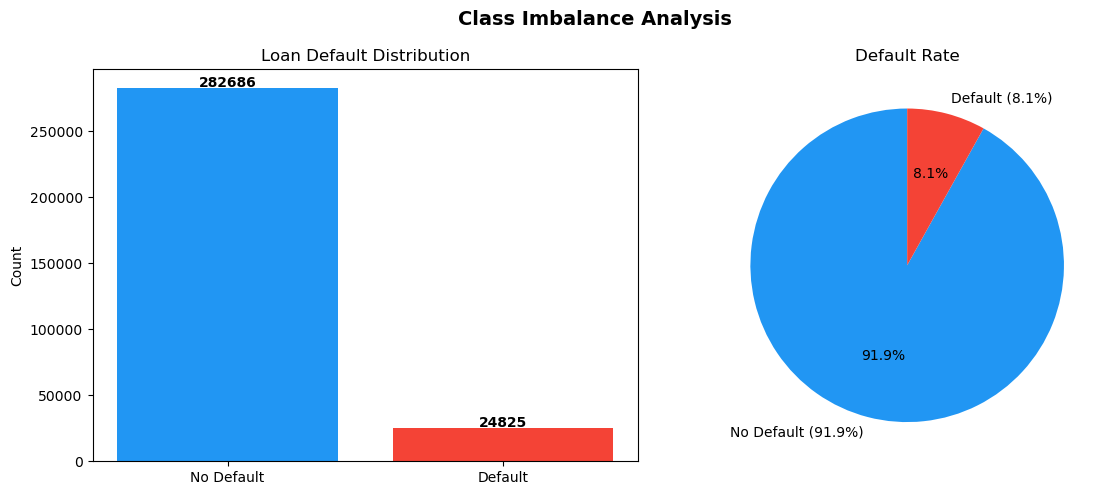

In [17]:
# EDA - Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - Count
axes[0].bar(['No Default', 'Default'], 
            [282686, 24825], 
            color=['#2196F3', '#F44336'])
axes[0].set_title('Loan Default Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([282686, 24825]):
    axes[0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

# Plot 2 - Percentage
axes[1].pie([91.9, 8.1], 
            labels=['No Default (91.9%)', 'Default (8.1%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Default Rate')

plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()